In [2]:
print("Hello!!")

Hello!!


150 epochs with computation evaluation

BN only, GNN only, and Hybrid - comparison

[Bayesian] Epoch 0 | Train Loss: 0.8214 | Val Loss: 0.8199
[Bayesian] Epoch 10 | Train Loss: 0.7607 | Val Loss: 0.7470
[Bayesian] Epoch 20 | Train Loss: 0.6975 | Val Loss: 0.6931
[Bayesian] Epoch 30 | Train Loss: 0.6525 | Val Loss: 0.6498
[Bayesian] Epoch 40 | Train Loss: 0.6054 | Val Loss: 0.6030
[Bayesian] Epoch 50 | Train Loss: 0.5546 | Val Loss: 0.5695
[Bayesian] Epoch 60 | Train Loss: 0.5292 | Val Loss: 0.5251
[Bayesian] Epoch 70 | Train Loss: 0.4918 | Val Loss: 0.4940
[Bayesian] Epoch 80 | Train Loss: 0.4656 | Val Loss: 0.4709
[Bayesian] Epoch 90 | Train Loss: 0.4522 | Val Loss: 0.4438
[Bayesian] Epoch 100 | Train Loss: 0.4273 | Val Loss: 0.4200
[Bayesian] Epoch 110 | Train Loss: 0.4071 | Val Loss: 0.4003
[Bayesian] Epoch 120 | Train Loss: 0.3808 | Val Loss: 0.3839
[Bayesian] Epoch 130 | Train Loss: 0.3656 | Val Loss: 0.3643
[Bayesian] Epoch 140 | Train Loss: 0.3515 | Val Loss: 0.3516
[GNN] Epoch 0 | Train Loss: 0.7300 | Val Loss: 0.7131
[GNN] Epoch 10 | Train Loss: 0.5881 | Val 

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(



=== Detailed Evaluation Metrics ===

--- Bayes only ---
Accuracy  : 0.8971
Precision : 0.9361
Recall    : 0.8726
F1-Score  : 0.9032
FPR       : 0.0729
FNR       : 0.1274

--- GNN only ---
Accuracy  : 0.9981
Precision : 0.9994
Recall    : 0.9971
F1-Score  : 0.9983
FPR       : 0.0007
FNR       : 0.0029

--- GNN+Bayes+RL ---
Accuracy  : 0.8506
Precision : 0.8566
Recall    : 0.8751
F1-Score  : 0.8657
FPR       : 0.1794
FNR       : 0.1249



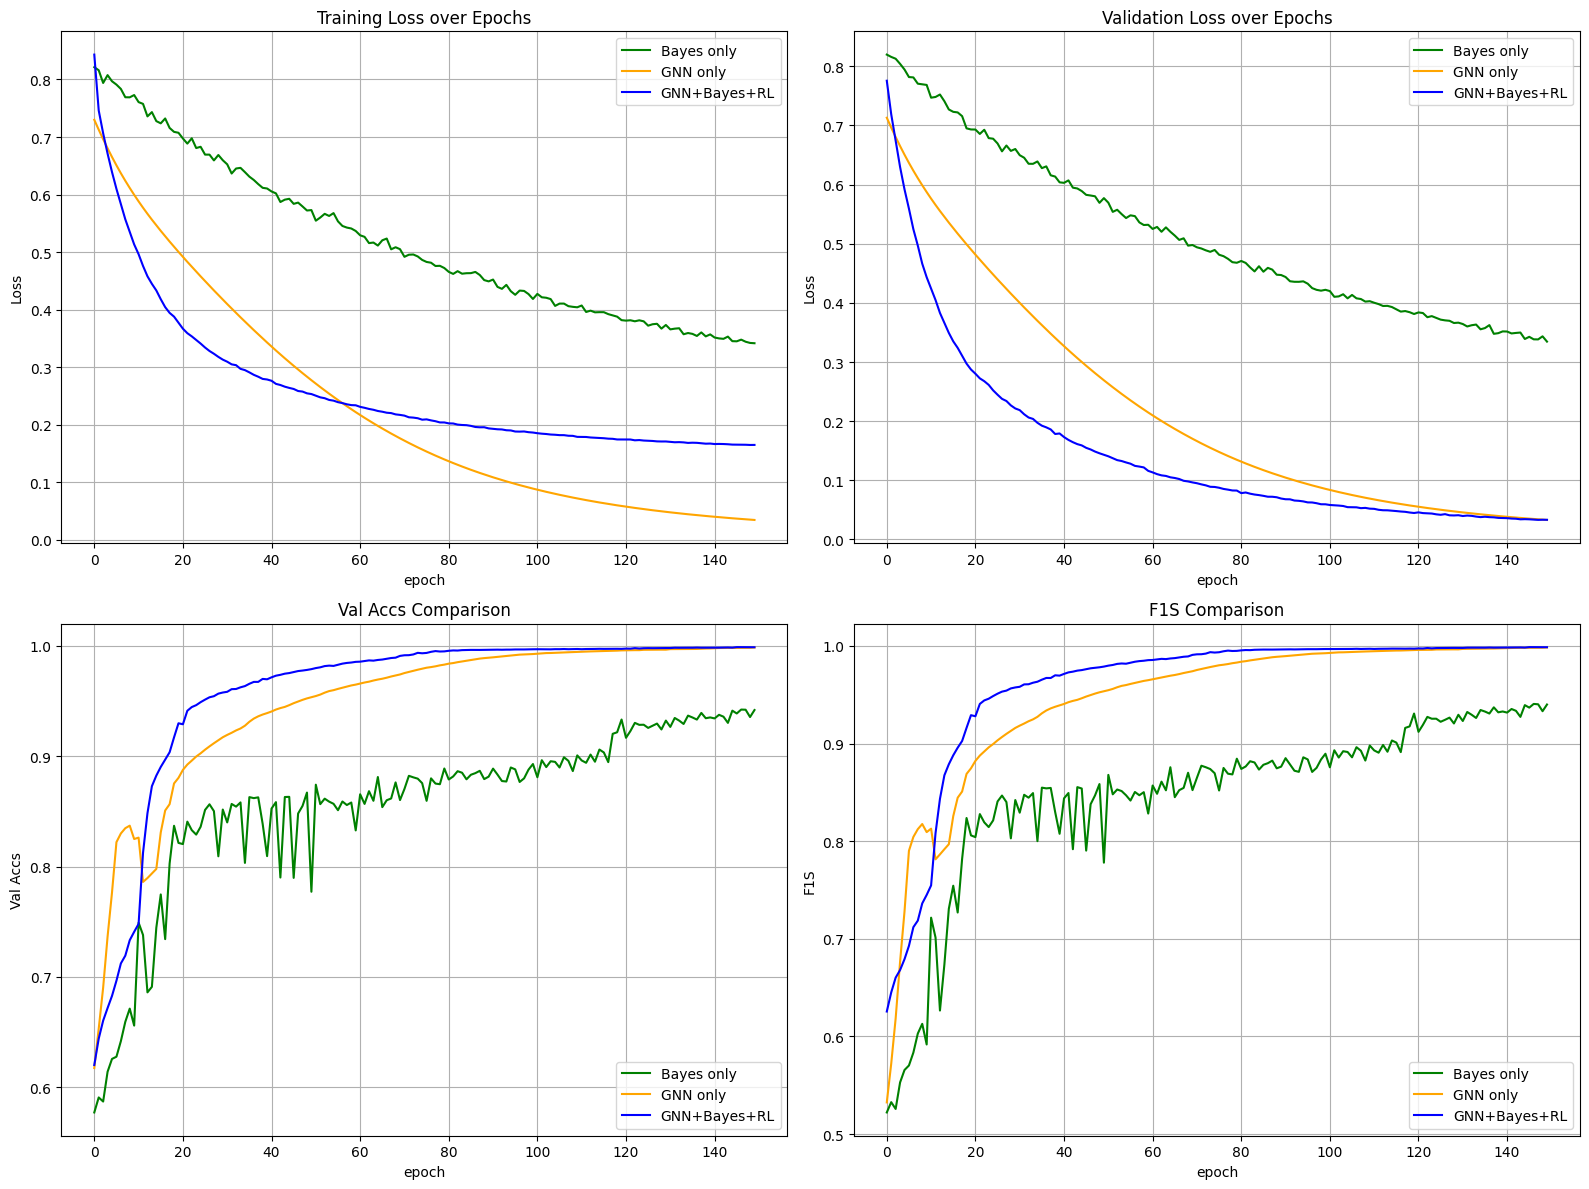

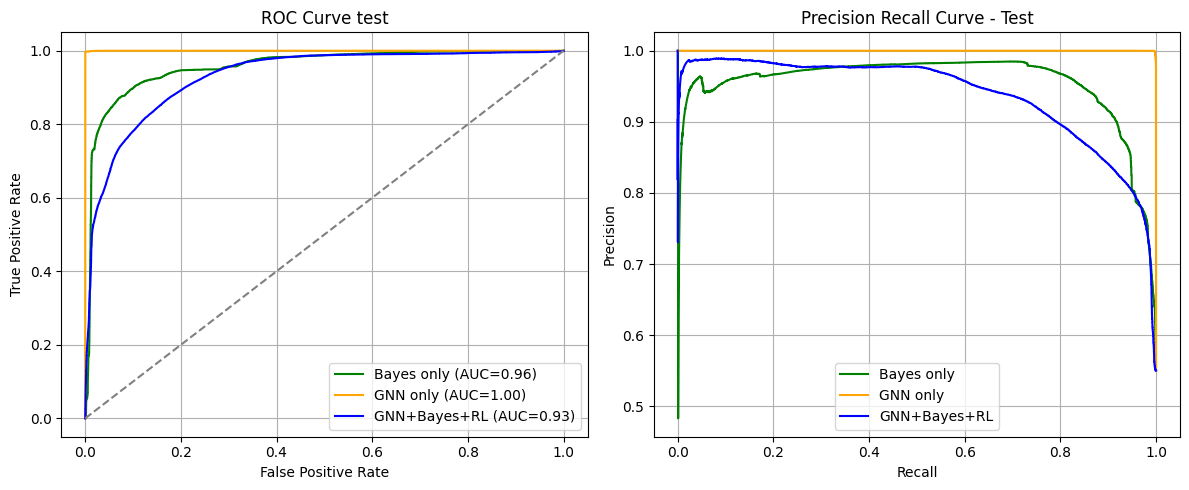

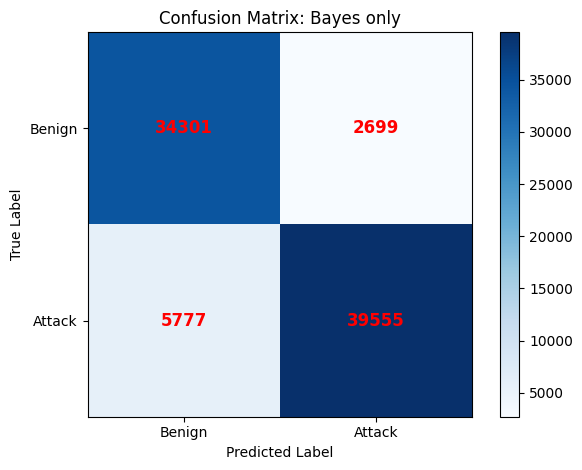

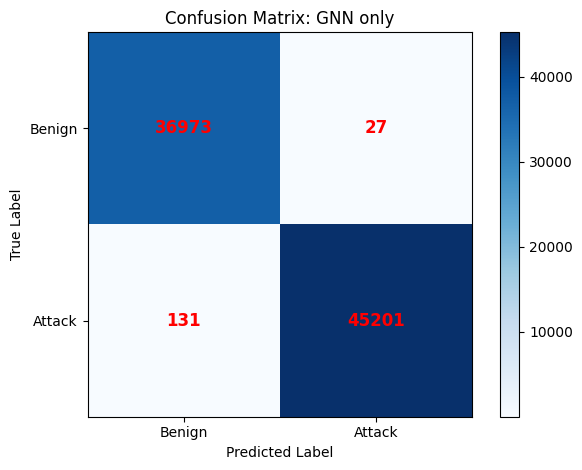

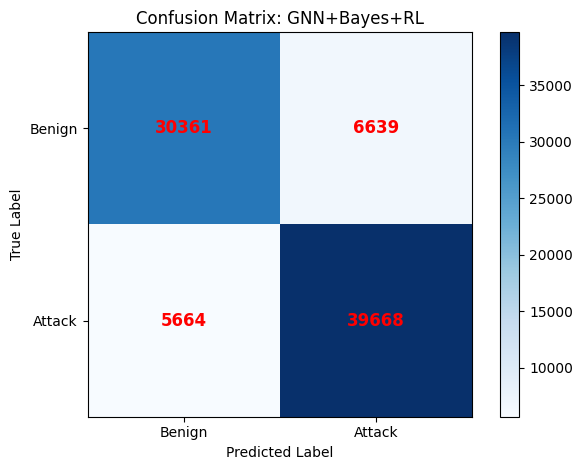

In [8]:
import random
import time
import psutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import torch_geometric.nn as pyg_nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from stable_baselines3 import PPO
from gym import Env
from gym.spaces import Box
import matplotlib.pyplot as plt

# ====== Set Seed for Reproducibility ======
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

# ====== Load & Preprocess Data ======
def load_data():
    train_df = pd.read_parquet("UNSW_NB15_training-set.parquet")
    test_df = pd.read_parquet("UNSW_NB15_testing-set.parquet")

    train_df = pd.get_dummies(train_df, drop_first=True)
    test_df = pd.get_dummies(test_df, drop_first=True)
    test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

    imputer = SimpleImputer(strategy='mean')
    train_df = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)
    test_df = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns)

    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']
    X_test = test_df.drop(columns=['label'])
    y_test = test_df['label']

    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_resampled)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, y_resampled.values, X_test_scaled, y_test.values

# ====== Models ======
class BayesianLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.rho = nn.Parameter(torch.Tensor(out_features, in_features))
        self.epsilon = Normal(0, 1)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.mu)
        nn.init.constant_(self.rho, -5)

    def forward(self, x):
        sigma = torch.log1p(torch.exp(self.rho))
        weight = self.mu + sigma * self.epsilon.sample(self.mu.shape)
        return torch.matmul(x, weight.t())

class BayesianModel(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.bayes = BayesianLayer(in_features, out_features)

    def forward(self, x):
        x = self.bayes(x)
        return torch.sigmoid(x)

class GNNModel(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.linear = pyg_nn.Linear(in_features, hidden_features)
        self.output = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.linear(x).relu()
        x = self.output(x)
        return torch.sigmoid(x)

from sklearn.neighbors import kneighbors_graph
from torch_geometric.utils import dense_to_sparse
from sklearn.neighbors import NearestNeighbors
import torch_geometric.utils as pyg_utils
from torch_geometric.nn import GCNConv

class HybridModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, k=5):
        super(HybridModel, self).__init__()
        self.gcn = GCNConv(input_dim, hidden_dim)
        self.bayes = BayesianLayer(hidden_dim, output_dim)
        self.k = k
        self.edge_index = None

    def build_graph(self, x):
        x_np = x.cpu().detach().numpy()
        nbrs = NearestNeighbors(n_neighbors=self.k).fit(x_np)
        distances, indices = nbrs.kneighbors(x_np)

        source_nodes = []
        target_nodes = []
        for i in range(indices.shape[0]):
            for j in range(indices.shape[1]):
                source_nodes.append(i)
                target_nodes.append(indices[i, j])

        edge_index = torch.tensor([source_nodes, target_nodes], dtype=torch.long).to(x.device)
        return edge_index

    def forward(self, x):
        if self.edge_index is None or self.edge_index.max().item() >= x.size(0):
            self.edge_index = self.build_graph(x)

        x = self.gcn(x, self.edge_index)
        x = self.bayes(x)
        return torch.sigmoid(x)

# ====== RL Threshold Optimizer ======
class ThresholdEnv(Env):
    def __init__(self, gnn_output, true_labels):
        super().__init__()
        self.gnn_output = gnn_output
        self.labels = true_labels
        self.threshold = 0.5
        self.action_space = Box(low=-0.1, high=0.1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        self.state = np.array([self.threshold], dtype=np.float32)

    def step(self, action):
        self.threshold += action[0]
        self.threshold = np.clip(self.threshold, 0.0, 1.0)
        preds = (self.gnn_output >= self.threshold).astype(int)
        reward = f1_score(self.labels, preds)
        return np.array([self.threshold], dtype=np.float32), reward, True, {}

    def reset(self):
        self.threshold = 0.5
        return np.array([self.threshold], dtype=np.float32)

    def seed(self, seed=None):
        np.random.seed(seed)

# ====== Training Loop with Logging ======
def train_model(model, X_train, y_train, X_val, y_val, epochs=150, name='Model'):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()
    train_loss_list = []
    val_loss_list = []
    val_acc_list = []
    val_f1_list = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_loss_list.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            preds = (val_output >= 0.5).int()
            acc = accuracy_score(y_val.numpy(), preds.numpy())
            f1 = f1_score(y_val.numpy(), preds.numpy())
            val_loss_list.append(val_loss.item())
            val_acc_list.append(acc)
            val_f1_list.append(f1)

        if epoch % 10 == 0:
            print(f"[{name}] Epoch {epoch} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    return model, train_loss_list, val_loss_list, val_acc_list, val_f1_list

# ====== Evaluation ======
def evaluate_model(model, X_test, y_test, use_rl=False):
    model.eval()
    with torch.no_grad():
        preds_prob = model(X_test).cpu().numpy().flatten()

    if use_rl:
        env = ThresholdEnv(preds_prob, y_test)
        rl_model = PPO("MlpPolicy", env, seed=42, verbose=0)
        rl_model.learn(total_timesteps=1000)
        threshold = env.threshold
    else:
        threshold = 0.5

    preds = (preds_prob >= threshold).astype(int)
    return {
        'acc': accuracy_score(y_test, preds),
        'prec': precision_score(y_test, preds),
        'rec': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'auc': roc_auc_score(y_test, preds_prob),
        'confusion': confusion_matrix(y_test, preds),
        'probs': preds_prob,
        'preds': preds,
        'threshold': threshold
    }

# ====== Plotting ======
def plot_metrics(metrics_dict):
    plt.figure(figsize=(16, 12))

    # Training Loss
    plt.subplot(2, 2, 1)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['train_loss'], label=key, color=color)
    plt.title("Training Loss over Epochs")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # Validation Loss
    plt.subplot(2, 2, 2)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['val_loss'], label=key, color=color)
    plt.title("Validation Loss over Epochs")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # Validation Accuracy
    plt.subplot(2, 2, 3)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['val_acc'], label=key, color=color)
    plt.title("Val Accs Comparison")
    plt.xlabel("epoch")
    plt.ylabel("Val Accs")
    plt.legend()
    plt.grid()

    # Validation F1 Score
    plt.subplot(2, 2, 4)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['val_f1'], label=key, color=color)
    plt.title("F1S Comparison")
    plt.xlabel("epoch")
    plt.ylabel("F1S")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(results, y_test):
    plt.figure(figsize=(12, 5))

    # ROC Curve
    plt.subplot(1, 2, 1)
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res['probs'])
        color = 'blue' if name == 'GNN+Bayes+RL' else 'orange' if name == 'GNN only' else 'green'
        plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=color)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("ROC Curve test")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()

    # Precision-Recall Curve
    plt.subplot(1, 2, 2)
    for name, res in results.items():
        prec, rec, _ = precision_recall_curve(y_test, res['probs'])
        color = 'blue' if name == 'GNN+Bayes+RL' else 'orange' if name == 'GNN only' else 'green'
        plt.plot(rec, prec, label=name, color=color)
    plt.title("Precision Recall Curve - Test")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(results):
    class_names = ["Benign", "Attack"]  # Labels for axes
    for name, res in results.items():
        cm = res['confusion']
        plt.figure()
        plt.title(f"Confusion Matrix: {name}")
        plt.imshow(cm, cmap='Blues', interpolation='nearest')
        plt.colorbar()
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names)
        plt.yticks(tick_marks, class_names)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")

        # Add values inside the matrix
        for (i, j), val in np.ndenumerate(cm):
            plt.text(j, i, f"{val}", ha='center', va='center', color='red', fontsize=12, weight='bold')

        plt.tight_layout()
        plt.show()

# ====== Metrics Calculation ======
def calculate_metrics(results_dict):
    print("\n=== Detailed Evaluation Metrics ===\n")
    for name, res in results_dict.items():
        cm = res['confusion']
        tn, fp, fn, tp = cm.ravel()

        acc = res['acc']
        prec = res['prec']
        rec = res['rec']
        f1 = res['f1']
        fpr = fp / (fp + tn) if (fp + tn) != 0 else 0
        fnr = fn / (fn + tp) if (fn + tp) != 0 else 0

        print(f"--- {name} ---")
        print(f"Accuracy  : {acc:.4f}")
        print(f"Precision : {prec:.4f}")
        print(f"Recall    : {rec:.4f}")
        print(f"F1-Score  : {f1:.4f}")
        print(f"FPR       : {fpr:.4f}")
        print(f"FNR       : {fnr:.4f}\n")

# ====== Main Pipeline ======
set_seeds(42)
X_train, y_train, X_test, y_test = load_data()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Split train/val
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.2, random_state=42)

metrics = {}
results = {}

# Bayesian Model
bayes_model = BayesianModel(X_train.shape[1], 1)
bayes_model, tl, vl, va, vf = train_model(bayes_model, X_train_final, y_train_final, X_val, y_val, name='Bayesian')
metrics['Bayes only'] = {'train_loss': tl, 'val_loss': vl, 'val_acc': va, 'val_f1': vf}
results['Bayes only'] = evaluate_model(bayes_model, X_test_tensor, y_test)

# GNN Model
gnn_model = GNNModel(X_train.shape[1], 64, 1)
gnn_model, tl, vl, va, vf = train_model(gnn_model, X_train_final, y_train_final, X_val, y_val, name='GNN')
metrics['GNN only'] = {'train_loss': tl, 'val_loss': vl, 'val_acc': va, 'val_f1': vf}
results['GNN only'] = evaluate_model(gnn_model, X_test_tensor, y_test)

# Hybrid Model
hybrid_model = HybridModel(X_train.shape[1], 64, 1)
hybrid_model, tl, vl, va, vf = train_model(hybrid_model, X_train_final, y_train_final, X_val, y_val, name='Hybrid')
metrics['GNN+Bayes+RL'] = {'train_loss': tl, 'val_loss': vl, 'val_acc': va, 'val_f1': vf}
results['GNN+Bayes+RL'] = evaluate_model(hybrid_model, X_test_tensor, y_test, use_rl=True)

# Call the function to display metrics
calculate_metrics(results)
# Plotting All
plot_metrics(metrics)
plot_roc_pr_curves(results, y_test)
plot_confusion_matrices(results)

[Bayesian] Epoch 0 | Train Loss: 0.8214 | Val Loss: 0.8199
[Bayesian] Epoch 10 | Train Loss: 0.7607 | Val Loss: 0.7470
[Bayesian] Epoch 20 | Train Loss: 0.6975 | Val Loss: 0.6931
[Bayesian] Epoch 30 | Train Loss: 0.6525 | Val Loss: 0.6498
[Bayesian] Epoch 40 | Train Loss: 0.6054 | Val Loss: 0.6030
[Bayesian] Epoch 50 | Train Loss: 0.5546 | Val Loss: 0.5695
[Bayesian] Epoch 60 | Train Loss: 0.5292 | Val Loss: 0.5251
[Bayesian] Epoch 70 | Train Loss: 0.4918 | Val Loss: 0.4940
[Bayesian] Epoch 80 | Train Loss: 0.4656 | Val Loss: 0.4709
[Bayesian] Epoch 90 | Train Loss: 0.4522 | Val Loss: 0.4438
[Bayesian] Epoch 100 | Train Loss: 0.4273 | Val Loss: 0.4200
[Bayesian] Epoch 110 | Train Loss: 0.4071 | Val Loss: 0.4003
[Bayesian] Epoch 120 | Train Loss: 0.3808 | Val Loss: 0.3839
[Bayesian] Epoch 130 | Train Loss: 0.3656 | Val Loss: 0.3643
[Bayesian] Epoch 140 | Train Loss: 0.3515 | Val Loss: 0.3516
[GNN] Epoch 0 | Train Loss: 0.7300 | Val Loss: 0.7131
[GNN] Epoch 10 | Train Loss: 0.5881 | Val 

c:\Users\admin\AppData\Local\Programs\Python\Python312\Lib\site-packages\stable_baselines3\common\vec_env\patch_gym.py:49: UserWarning: You provided an OpenAI Gym environment. We strongly recommend transitioning to Gymnasium environments. Stable-Baselines3 is automatically wrapping your environments in a compatibility layer, which could potentially cause issues.
  warnings.warn(


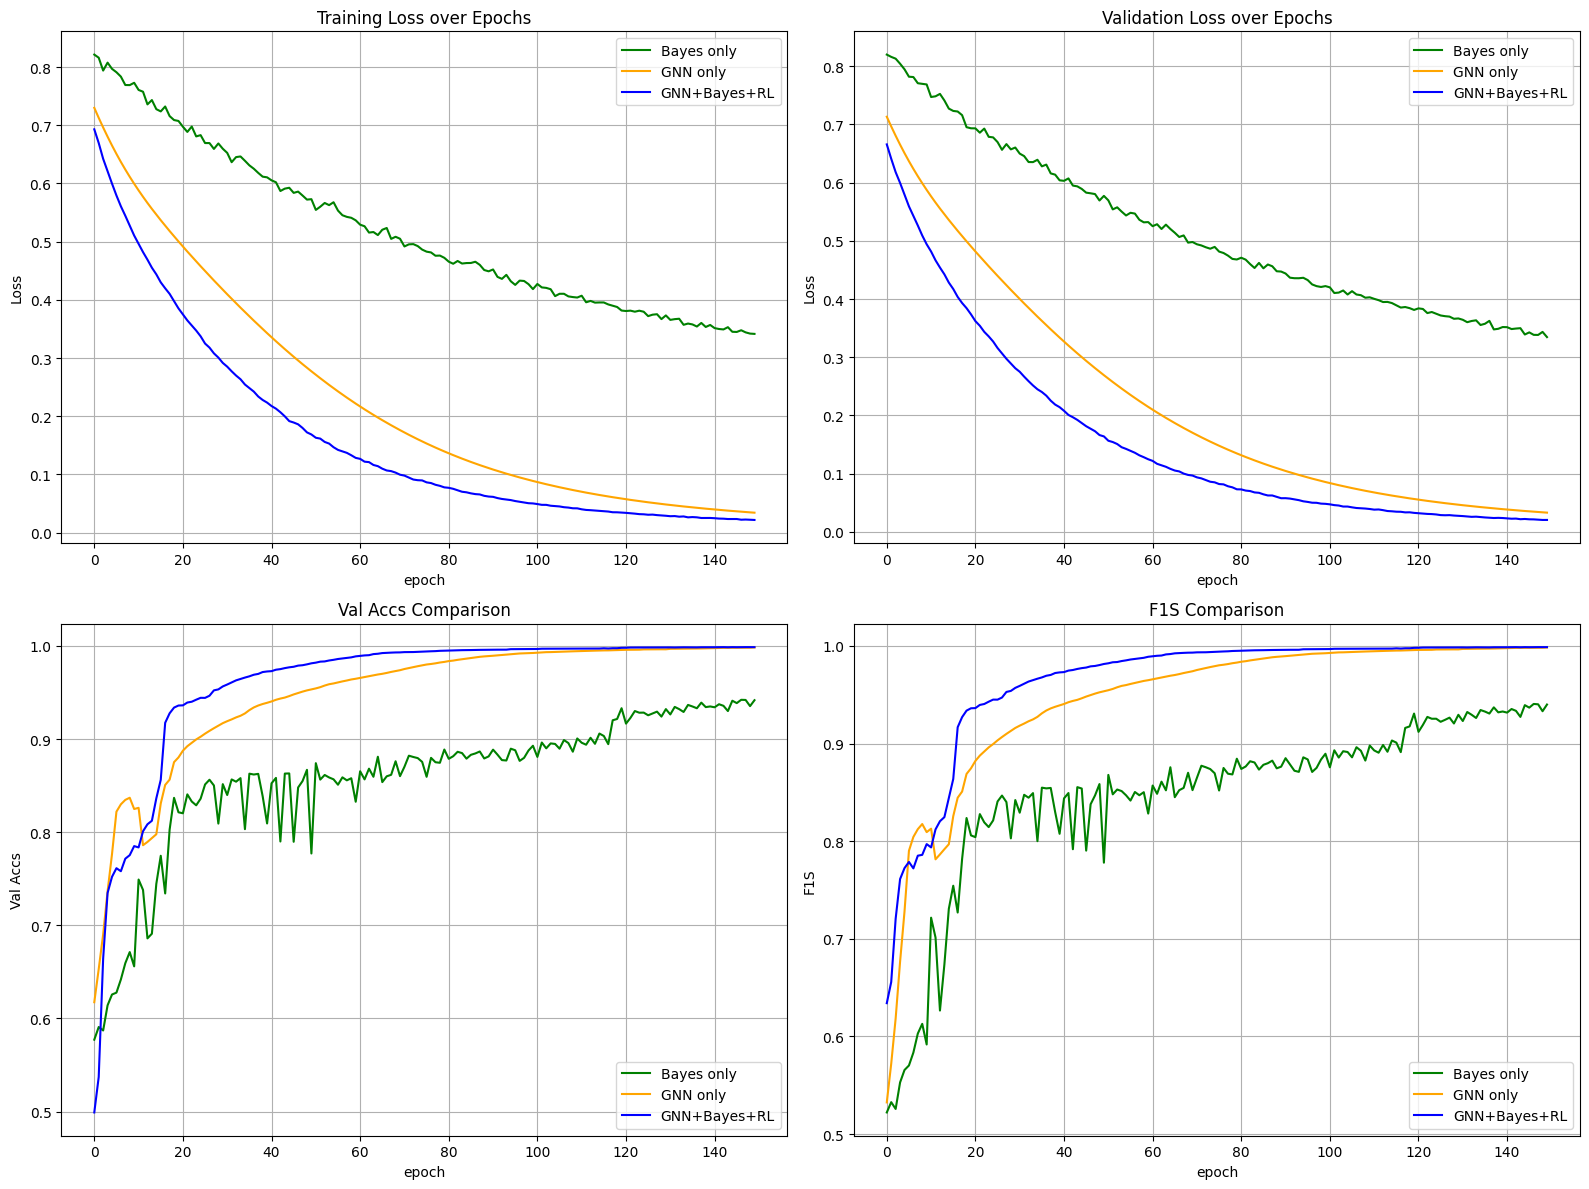

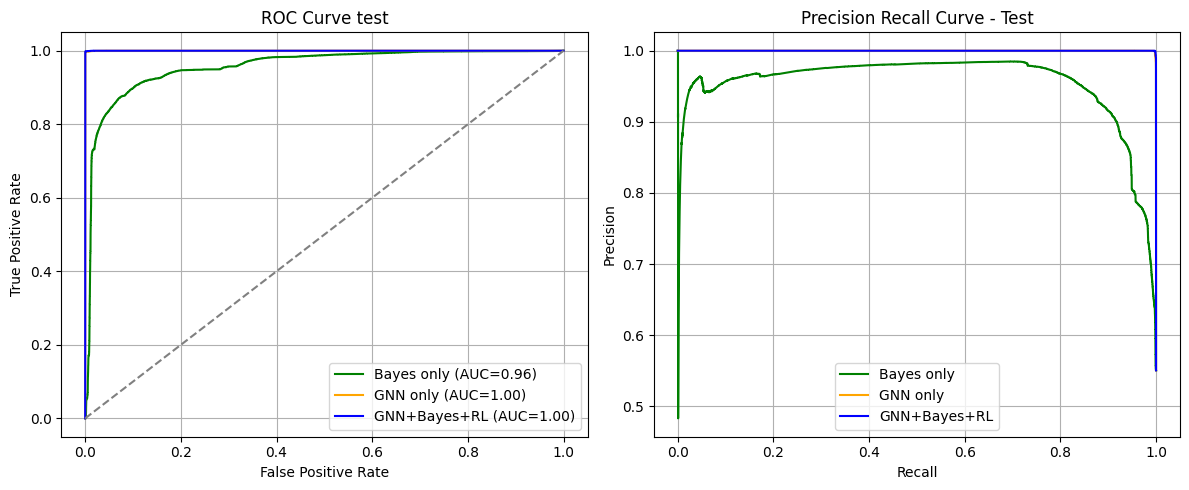

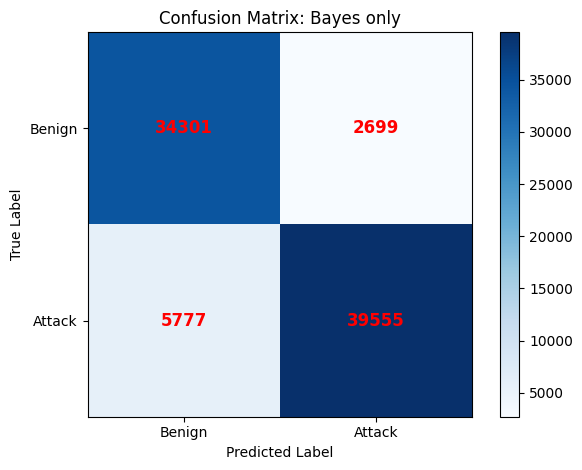

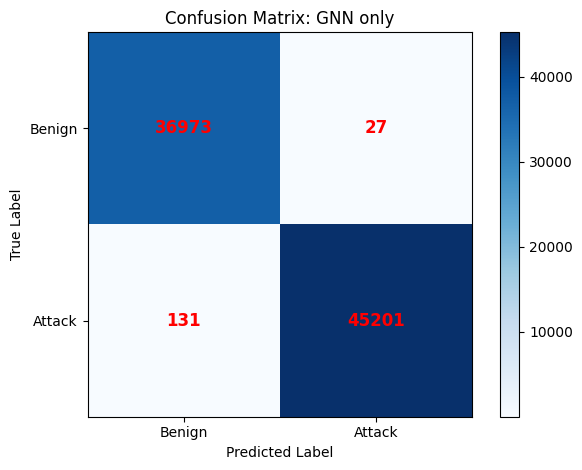

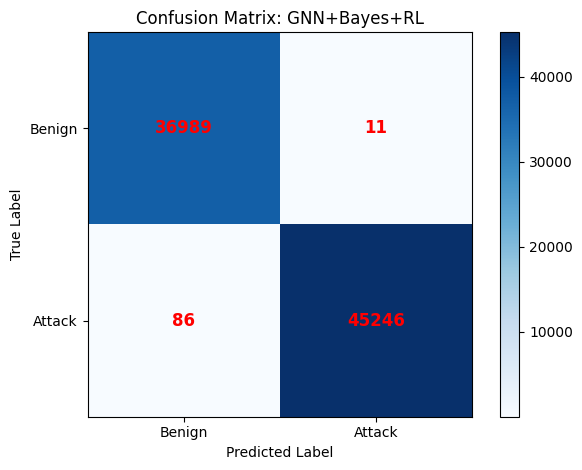


=== Final Metrics for Each Model (Best Configuration) ===

--- Bayes only ---
Threshold : 0.5000
Accuracy  : 0.8971
Precision : 0.9361
Recall    : 0.8726
F1-Score  : 0.9032
FPR       : 0.0729
FNR       : 0.1274

--- GNN only ---
Threshold : 0.5000
Accuracy  : 0.9981
Precision : 0.9994
Recall    : 0.9971
F1-Score  : 0.9983
FPR       : 0.0007
FNR       : 0.0029

--- GNN+Bayes+RL ---
Threshold : 0.5000
Accuracy  : 0.9988
Precision : 0.9998
Recall    : 0.9981
F1-Score  : 0.9989
FPR       : 0.0003
FNR       : 0.0019



In [7]:
import random
import time
import psutil
import torch
import torch.nn as nn
import torch.optim as optim
from torch.distributions import Normal
import torch_geometric.nn as pyg_nn
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, roc_curve, precision_recall_curve
)
from imblearn.over_sampling import SMOTE
from stable_baselines3 import PPO
from gym import Env
from gym.spaces import Box
import matplotlib.pyplot as plt

# ====== Set Seed for Reproducibility ======
def set_seeds(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

# ====== Load & Preprocess Data ======
def load_data():
    train_df = pd.read_parquet("UNSW_NB15_training-set.parquet")
    test_df = pd.read_parquet("UNSW_NB15_testing-set.parquet")

    train_df = pd.get_dummies(train_df, drop_first=True)
    test_df = pd.get_dummies(test_df, drop_first=True)
    test_df = test_df.reindex(columns=train_df.columns, fill_value=0)

    imputer = SimpleImputer(strategy='mean')
    train_df = pd.DataFrame(imputer.fit_transform(train_df), columns=train_df.columns)
    test_df = pd.DataFrame(imputer.transform(test_df), columns=test_df.columns)

    X_train = train_df.drop(columns=['label'])
    y_train = train_df['label']
    X_test = test_df.drop(columns=['label'])
    y_test = test_df['label']

    smote = SMOTE(random_state=42)
    X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_resampled)
    X_test_scaled = scaler.transform(X_test)

    return X_train_scaled, y_resampled.values, X_test_scaled, y_test.values

# ====== Models ======
class BayesianLayer(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.mu = nn.Parameter(torch.Tensor(out_features, in_features))
        self.rho = nn.Parameter(torch.Tensor(out_features, in_features))
        self.epsilon = Normal(0, 1)
        self.reset_parameters()

    def reset_parameters(self):
        nn.init.xavier_uniform_(self.mu)
        nn.init.constant_(self.rho, -5)

    def forward(self, x):
        sigma = torch.log1p(torch.exp(self.rho))
        weight = self.mu + sigma * self.epsilon.sample(self.mu.shape)
        return torch.matmul(x, weight.t())

class BayesianModel(nn.Module):
    def __init__(self, in_features, out_features):
        super().__init__()
        self.bayes = BayesianLayer(in_features, out_features)

    def forward(self, x):
        x = self.bayes(x)
        return torch.sigmoid(x)

class GNNModel(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.linear = pyg_nn.Linear(in_features, hidden_features)
        self.output = nn.Linear(hidden_features, out_features)

    def forward(self, x):
        x = self.linear(x).relu()
        x = self.output(x)
        return torch.sigmoid(x)

class HybridModel(nn.Module):
    def __init__(self, in_features, hidden_features, out_features):
        super().__init__()
        self.linear = pyg_nn.Linear(in_features, hidden_features)
        self.bayes = BayesianLayer(hidden_features, out_features)

    def forward(self, x):
        x = self.linear(x).relu()
        x = self.bayes(x)
        return torch.sigmoid(x)

# ====== RL Threshold Optimizer ======
class ThresholdEnv(Env):
    def __init__(self, gnn_output, true_labels):
        super().__init__()
        self.gnn_output = gnn_output
        self.labels = true_labels
        self.threshold = 0.5
        self.action_space = Box(low=-0.1, high=0.1, shape=(1,), dtype=np.float32)
        self.observation_space = Box(low=0.0, high=1.0, shape=(1,), dtype=np.float32)
        self.state = np.array([self.threshold], dtype=np.float32)

    def step(self, action):
        self.threshold += action[0]
        self.threshold = np.clip(self.threshold, 0.0, 1.0)
        preds = (self.gnn_output >= self.threshold).astype(int)
        reward = f1_score(self.labels, preds)
        return np.array([self.threshold], dtype=np.float32), reward, True, {}

    def reset(self):
        self.threshold = 0.5
        return np.array([self.threshold], dtype=np.float32)

    def seed(self, seed=None):
        np.random.seed(seed)

# ====== Training Loop with Logging ======
def train_model(model, X_train, y_train, X_val, y_val, epochs=150, name='Model'):
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()
    train_loss_list = []
    val_loss_list = []
    val_acc_list = []
    val_f1_list = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output = model(X_train)
        loss = criterion(output, y_train)
        loss.backward()
        optimizer.step()
        train_loss_list.append(loss.item())

        model.eval()
        with torch.no_grad():
            val_output = model(X_val)
            val_loss = criterion(val_output, y_val)
            preds = (val_output >= 0.5).int()
            acc = accuracy_score(y_val.numpy(), preds.numpy())
            f1 = f1_score(y_val.numpy(), preds.numpy())
            val_loss_list.append(val_loss.item())
            val_acc_list.append(acc)
            val_f1_list.append(f1)

        if epoch % 10 == 0:
            print(f"[{name}] Epoch {epoch} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

    return model, train_loss_list, val_loss_list, val_acc_list, val_f1_list

# ====== Evaluation ======
def evaluate_model(model, X_test, y_test, use_rl=False):
    model.eval()
    with torch.no_grad():
        preds_prob = model(X_test).cpu().numpy().flatten()

    if use_rl:
        env = ThresholdEnv(preds_prob, y_test)
        rl_model = PPO("MlpPolicy", env, seed=42, verbose=0)
        rl_model.learn(total_timesteps=1000)
        threshold = env.threshold
    else:
        threshold = 0.5

    preds = (preds_prob >= threshold).astype(int)
    return {
        'acc': accuracy_score(y_test, preds),
        'prec': precision_score(y_test, preds),
        'rec': recall_score(y_test, preds),
        'f1': f1_score(y_test, preds),
        'auc': roc_auc_score(y_test, preds_prob),
        'confusion': confusion_matrix(y_test, preds),
        'probs': preds_prob,
        'preds': preds,
        'threshold': threshold
    }

# ====== Plotting ======
def plot_metrics(metrics_dict):
    plt.figure(figsize=(16, 12))

    # Training Loss
    plt.subplot(2, 2, 1)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['train_loss'], label=key, color=color)
    plt.title("Training Loss over Epochs")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # Validation Loss
    plt.subplot(2, 2, 2)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['val_loss'], label=key, color=color)
    plt.title("Validation Loss over Epochs")
    plt.xlabel("epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid()

    # Validation Accuracy
    plt.subplot(2, 2, 3)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['val_acc'], label=key, color=color)
    plt.title("Val Accs Comparison")
    plt.xlabel("epoch")
    plt.ylabel("Val Accs")
    plt.legend()
    plt.grid()

    # Validation F1 Score
    plt.subplot(2, 2, 4)
    for key in metrics_dict:
        color = 'blue' if key == 'GNN+Bayes+RL' else 'orange' if key == 'GNN only' else 'green'
        plt.plot(metrics_dict[key]['val_f1'], label=key, color=color)
    plt.title("F1S Comparison")
    plt.xlabel("epoch")
    plt.ylabel("F1S")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()


def plot_roc_pr_curves(results, y_test):
    plt.figure(figsize=(12, 5))

    # ROC Curve
    plt.subplot(1, 2, 1)
    for name, res in results.items():
        fpr, tpr, _ = roc_curve(y_test, res['probs'])
        color = 'blue' if name == 'GNN+Bayes+RL' else 'orange' if name == 'GNN only' else 'green'
        plt.plot(fpr, tpr, label=f"{name} (AUC={res['auc']:.2f})", color=color)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray")
    plt.title("ROC Curve test")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.grid()

    # Precision-Recall Curve
    plt.subplot(1, 2, 2)
    for name, res in results.items():
        prec, rec, _ = precision_recall_curve(y_test, res['probs'])
        color = 'blue' if name == 'GNN+Bayes+RL' else 'orange' if name == 'GNN only' else 'green'
        plt.plot(rec, prec, label=name, color=color)
    plt.title("Precision Recall Curve - Test")
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.legend()
    plt.grid()

    plt.tight_layout()
    plt.show()

def plot_confusion_matrices(results):
    class_names = ["Benign", "Attack"]  # Labels for axes
    for name, res in results.items():
        cm = res['confusion']
        plt.figure()
        plt.title(f"Confusion Matrix: {name}")
        plt.imshow(cm, cmap='Blues', interpolation='nearest')
        plt.colorbar()
        tick_marks = np.arange(len(class_names))
        plt.xticks(tick_marks, class_names)
        plt.yticks(tick_marks, class_names)
        plt.xlabel("Predicted Label")
        plt.ylabel("True Label")

        # Add values inside the matrix
        for (i, j), val in np.ndenumerate(cm):
            plt.text(j, i, f"{val}", ha='center', va='center', color='red', fontsize=12, weight='bold')

        plt.tight_layout()
        plt.show()

# ====== Fixed Metrics Calculation Based on Final Predictions ======
def calculate_fixed_metrics(results_dict):
    print("\n=== Final Metrics for Each Model (Best Configuration) ===\n")
    for name, res in results_dict.items():
        cm = res['confusion']
        tn, fp, fn, tp = cm.ravel()

        acc = res['acc']
        prec = res['prec']
        rec = res['rec']
        f1 = res['f1']
        fpr = fp / (fp + tn) if (fp + tn) > 0 else 0.0
        fnr = fn / (fn + tp) if (fn + tp) > 0 else 0.0

        print(f"--- {name} ---")
        print(f"Threshold : {res['threshold']:.4f}")
        print(f"Accuracy  : {acc:.4f}")
        print(f"Precision : {prec:.4f}")
        print(f"Recall    : {rec:.4f}")
        print(f"F1-Score  : {f1:.4f}")
        print(f"FPR       : {fpr:.4f}")
        print(f"FNR       : {fnr:.4f}\n")

# ====== Main Pipeline ======
set_seeds(42)
X_train, y_train, X_test, y_test = load_data()
X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
X_test_tensor = torch.tensor(X_test, dtype=torch.float32)
y_test_tensor = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)

# Split train/val
X_train_final, X_val, y_train_final, y_val = train_test_split(X_train_tensor, y_train_tensor, test_size=0.2, random_state=42)

metrics = {}
results = {}

# Bayesian Model
bayes_model = BayesianModel(X_train.shape[1], 1)
bayes_model, tl, vl, va, vf = train_model(bayes_model, X_train_final, y_train_final, X_val, y_val, name='Bayesian')
metrics['Bayes only'] = {'train_loss': tl, 'val_loss': vl, 'val_acc': va, 'val_f1': vf}
results['Bayes only'] = evaluate_model(bayes_model, X_test_tensor, y_test)

# GNN Model
gnn_model = GNNModel(X_train.shape[1], 64, 1)
gnn_model, tl, vl, va, vf = train_model(gnn_model, X_train_final, y_train_final, X_val, y_val, name='GNN')
metrics['GNN only'] = {'train_loss': tl, 'val_loss': vl, 'val_acc': va, 'val_f1': vf}
results['GNN only'] = evaluate_model(gnn_model, X_test_tensor, y_test)

# Hybrid Model
hybrid_model = HybridModel(X_train.shape[1], 64, 1)
hybrid_model, tl, vl, va, vf = train_model(hybrid_model, X_train_final, y_train_final, X_val, y_val, name='Hybrid')
metrics['GNN+Bayes+RL'] = {'train_loss': tl, 'val_loss': vl, 'val_acc': va, 'val_f1': vf}
results['GNN+Bayes+RL'] = evaluate_model(hybrid_model, X_test_tensor, y_test, use_rl=True)

# Plotting All
plot_metrics(metrics)
plot_roc_pr_curves(results, y_test)
plot_confusion_matrices(results)
# Call the function
calculate_fixed_metrics(results)